# Fit a single smooth

A GLM with a B-spline basis can model a tuning curve of unknown shape.
But the fit depends on the number of basis functions.
Too few functions miss the shape. Too many functions follow the noise.
The usual fix is to cross-validate over many basis sizes, which costs many fits.

A penalized GAM takes a different route.
It keeps one large basis and adds a penalty on the curvature of the fitted curve.
It estimates the strength of that penalty from the data, in one fit.

This notebook fits both models to the same data and compares them.

In [1]:
import jax
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

In [2]:
import nemos as nmo
import pandas as pd
from example_data import make_position_tuned_data
from example_plots import (
    ORANGE,
    PURPLE,
    add_rate_curve,
    plot_counts_and_truth,
    plot_design_recorded_and_sorted,
    set_plot_style,
)
from scipy.stats import poisson

from pgam_jax import GAM

set_plot_style()

## The data

One neuron and one input, the position $x$.
We draw 320 positions $x \sim \mathrm{Uniform}(0, 1)$ and one spike count $y$ for each:

$$\log \lambda(x) = -1.25 + 2.25 \exp\left(-\frac{(x - 0.57)^2}{2 \cdot 0.13^2}\right) + 0.65 \exp\left(-\frac{(x - 0.20)^2}{2 \cdot 0.075^2}\right)$$

$$y \sim \mathrm{Poisson}(\lambda(x))$$

The log-rate is a baseline plus two Gaussian bumps: a main field near 0.57 and a smaller shoulder near 0.2.

In [3]:
data = make_position_tuned_data()

In [4]:
for name in ["spikes", "position", "position_grid"]:
    label = f"Shape of data.{name}:"
    print(f"{label:<30}{getattr(data, name).shape}")
print()
print(f"Number of spikes: {data.spikes.sum()}")

Shape of data.spikes:         (320,)
Shape of data.position:       (320,)
Shape of data.position_grid:  (500,)

Number of spikes: 284


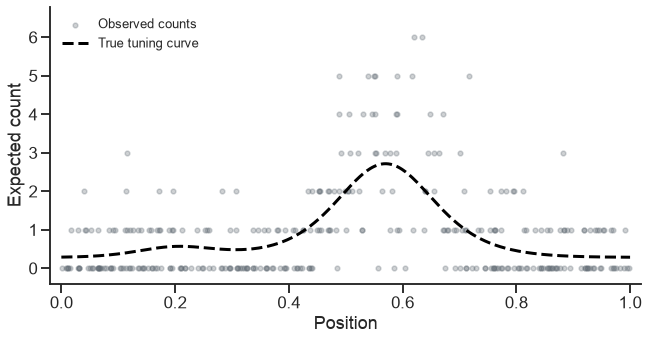

In [5]:
fig, ax = plot_counts_and_truth(data)
plt.show()

## Unpenalized GLM with a large basis

### Basis definition

In [6]:
# The number of B-spline functions. Shared by GLM and GAM.
N_BASIS = 30

In [7]:
basis = nmo.basis.BSplineEval(
    n_basis_funcs=N_BASIS,
    bounds=(0.0, 1.0),
    label="position",
)

**NOTE:** `pgam_jax` requires `bounds` to be set on evaluation bases.

### The design matrix

In [8]:
design = basis.compute_features(data.position)

print(f"Design matrix shape: {design.shape}")

Design matrix shape: (320, 30)


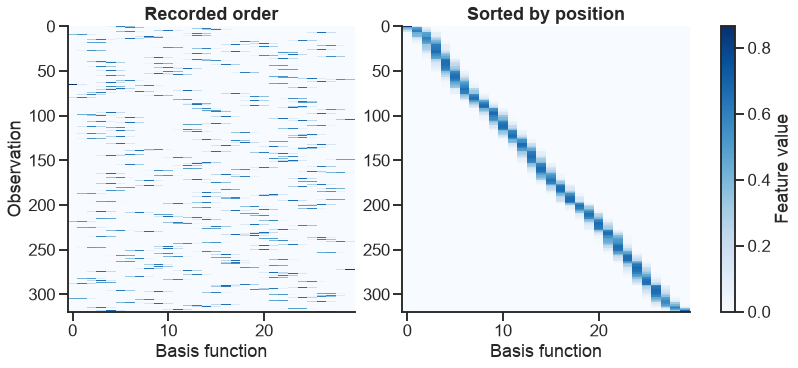

In [9]:
fig = plot_design_recorded_and_sorted(design, data.position)
plt.show()

### Unpenalized GLM

In [10]:
glm = nmo.glm.GLM()

glm.fit(design, data.spikes)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp at 0x1435f0e00>
,regularizer,UnRegularized()
,solver_name,'LBFGS'
,solver_kwargs,{}
,regularizer_strength,None
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](30,)",Array([-3.509...dtype=float64)
dof_resid_,"ArrayImpl[float64](1,)","Array([289.], dtype=float64)"
intercept_,"ArrayImpl[float64](1,)",Array([-0.620...dtype=float64)


In [11]:
design_grid = basis.compute_features(data.position_grid)

glm_rate = glm.predict(design_grid)

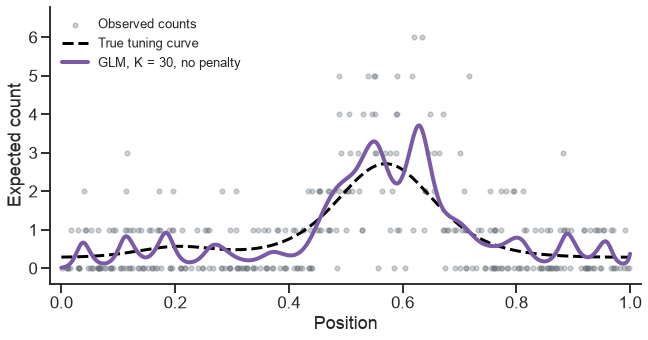

In [12]:
fig, ax = plot_counts_and_truth(data)
add_rate_curve(
    ax, data.position_grid, glm_rate, f"GLM, K = {N_BASIS}, no penalty", PURPLE
)
plt.show()

## Fit the GAM

In [13]:
gam = GAM(
    basis,  # uses the same nemos basis
    use_scipy=True,  # often faster on CPU
)

In [14]:
gam.fit(
    (data.position,),  # fit expects inputs as tuples
    data.spikes,  # the output/target is a single vector
)

## GAM recovers the true tuning curve

The penalty decides how much of the flexibility the fit actually uses.
That amount is the effective degrees of freedom.

In [15]:
gam_rate = gam.predict((data.position_grid,))

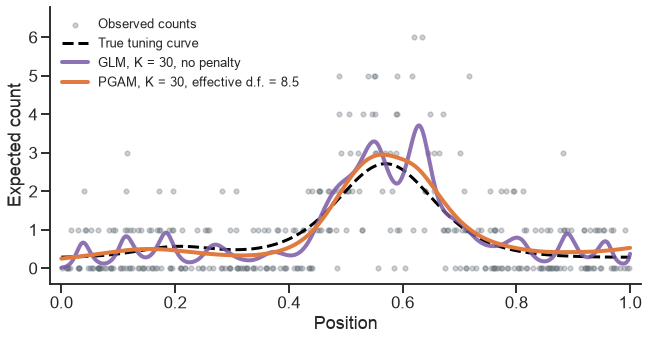

In [16]:
fig, ax = plot_counts_and_truth(data)
add_rate_curve(
    ax,
    data.position_grid,
    glm_rate,
    f"GLM, K = {N_BASIS}, no penalty",
    PURPLE,
    alpha=0.85,
)
add_rate_curve(
    ax,
    data.position_grid,
    gam_rate,
    f"PGAM, K = {N_BASIS}, effective d.f. = {float(gam.edf_):.1f}",
    ORANGE,
)
plt.show()

## Score on new data

`gam.score` returns the mean log-likelihood of the data under the fitted model. Higher is better.

A good fit must also predict data that it did not see.
Draw a new sample from the same model, with a different seed, and score both models on the training data and on the new data.
The true model gives a reference: no fit can be expected to do better on new data.

In [17]:
test_data = make_position_tuned_data(seed=123)
test_design = basis.compute_features(test_data.position)


def true_model_score(d):
    """Mean log-likelihood of the counts under the true rate."""
    return poisson.logpmf(d.spikes, d.true_rate).mean()


scores = pd.DataFrame(
    {
        "train": [
            float(glm.score(design, data.spikes)),
            float(gam.score((data.position,), data.spikes)),
            true_model_score(data),
        ],
        "test": [
            float(glm.score(test_design, test_data.spikes)),
            float(gam.score((test_data.position,), test_data.spikes)),
            true_model_score(test_data),
        ],
    },
    index=["GLM", "PGAM", "true model"],
)
scores.style.format("{:.3f}")

,train,test
GLM,-1.031,-1.143
PGAM,-1.072,-1.097
true model,-1.091,-1.087


The GLM scores best on the training data but worst on the new data: it fits the noise of the training sample.
The PGAM scores lower than the GLM on the training data, because the penalty keeps it from following that noise.
On the new data it scores close to the true model.